# ***Importing Libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ***Exploratory Data Analysis (EDA)***

In [3]:
df = pd.read_csv('/content/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.shape

(1338, 7)

In [6]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [10]:
df.describe(include='object').T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


In [23]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.drop_duplicates(inplace=True)

In [24]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [12]:
num_df = df.select_dtypes(include='number')
cat_df = df.select_dtypes(include='object')

In [13]:
num_df.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [14]:
num_df.corr()['charges'].sort_values(ascending=False)

,charges
charges,1.000000
age,0.299008
bmi,0.198341
children,0.067998


In [16]:
num_df.cov()

,age,bmi,children,charges
age,197.401387,9.362337,0.719303,5.087480e+04
bmi,9.362337,37.187884,0.093795,1.464730e+04
children,0.719303,0.093795,1.453213,9.926742e+02
charges,50874.802298,14647.304426,992.674197,1.466524e+08


In [17]:
num_df.skew()

,0
age,0.055673
bmi,0.284047
children,0.938380
charges,1.515880


In [18]:
num_df.kurtosis()

,0
age,-1.245088
bmi,-0.050732
children,0.202454
charges,1.606299


In [19]:
cat_df.nunique()

,0
sex,2
smoker,2
region,4


In [20]:
cat_df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [25]:
df.groupby('smoker')['charges'].mean()

,charges
smoker,
no,8440.660307
yes,32050.231832


In [26]:
df.groupby('region')['charges'].mean()

,charges
region,
northeast,13406.384516
northwest,12450.840844
southeast,14735.411438
southwest,12346.937377


In [27]:
df.groupby(['region', 'sex'])[['bmi', 'charges']].mean()

bmi       charges
region    sex                            
northeast female  29.324317  12953.203151
          male    29.024540  13854.005374
northwest female  29.277957  12479.870397
          male    29.110969  12421.085553
southeast female  32.671257  13499.669243
          male    33.990000  15879.617173
southwest female  30.060494  11274.411264
          male    31.129448  13412.883576

In [28]:
df.groupby('children')['charges'].agg(['count', 'mean'])

,count,mean
children,,
0,573,12384.695344
1,324,12731.171832
2,240,15073.563734
3,157,15355.318367
4,25,13850.656311
5,18,8786.035247


# *Data Visaulization*

<Axes: >

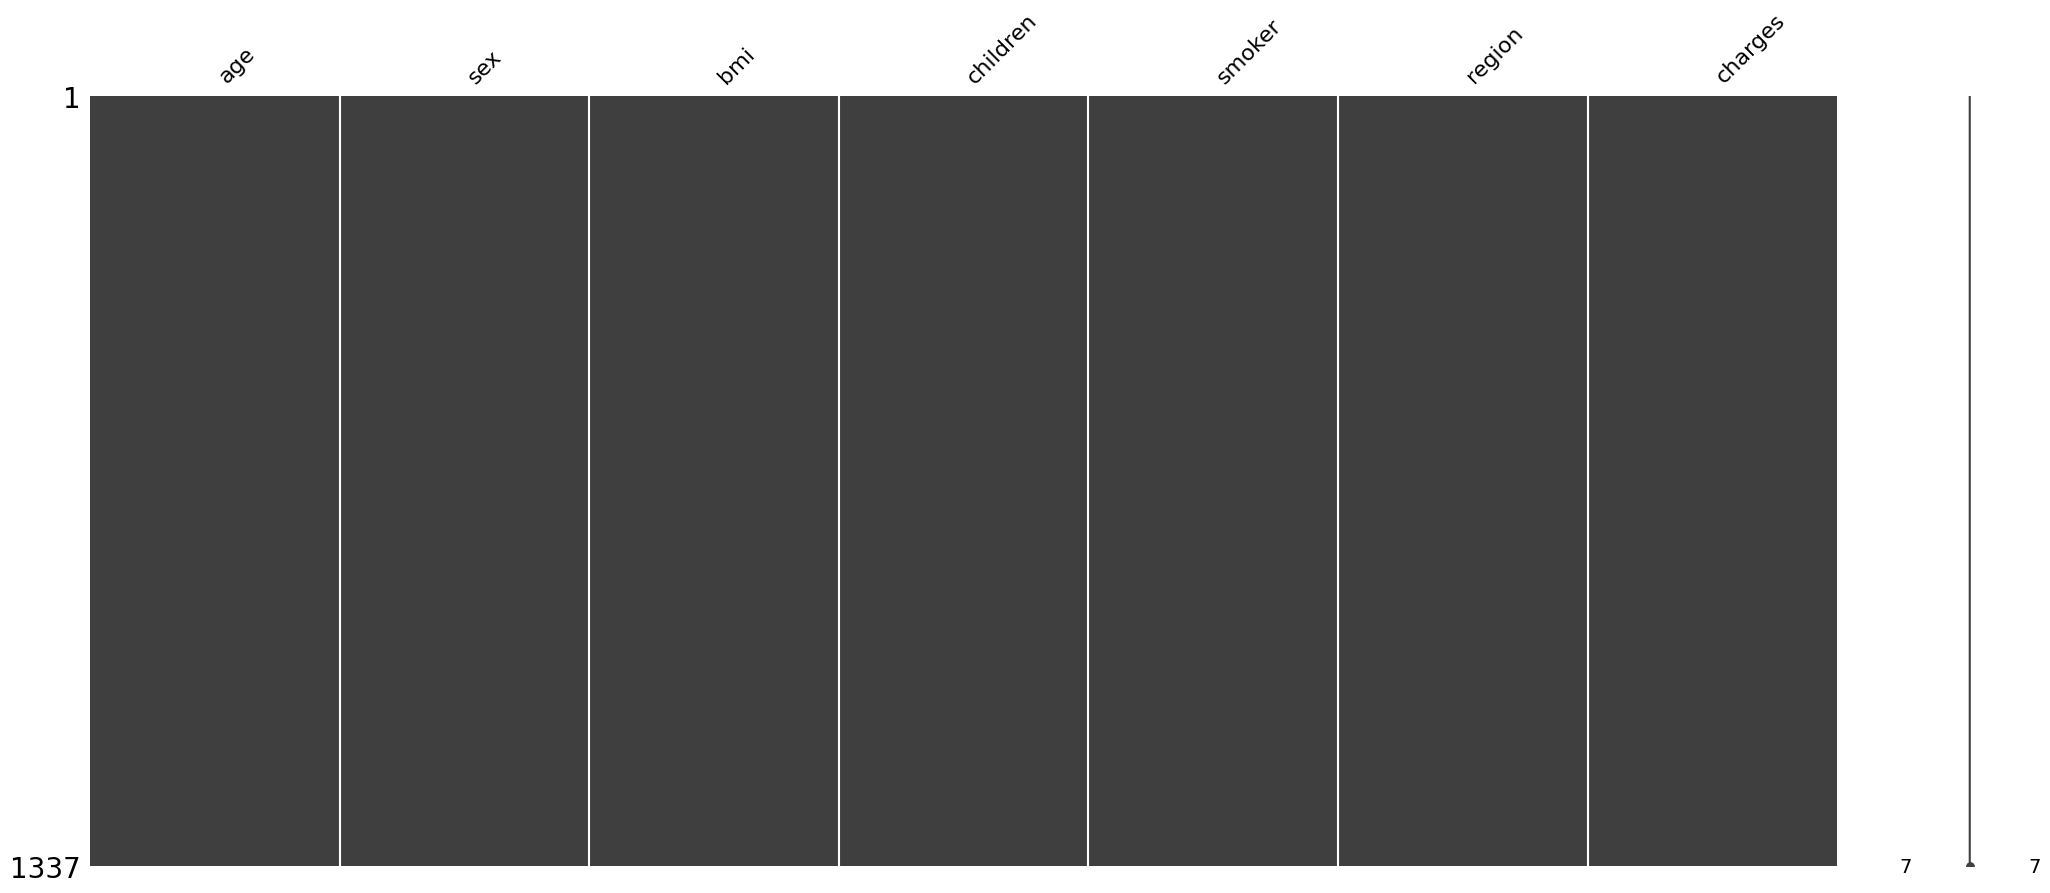

In [30]:
import missingno as msno
msno.matrix(df)

<Axes: >

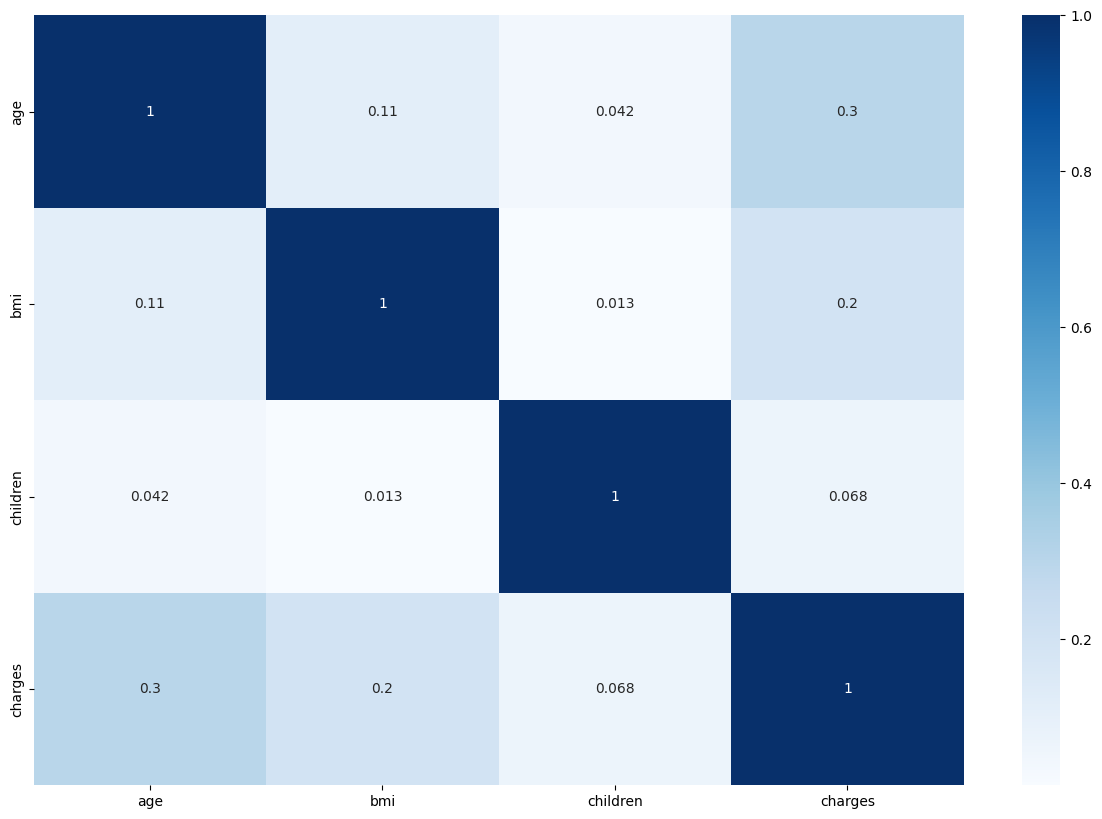

In [32]:
plt.figure(figsize=(15,10))
sns.heatmap(num_df.corr(),annot=True,cmap='Blues')

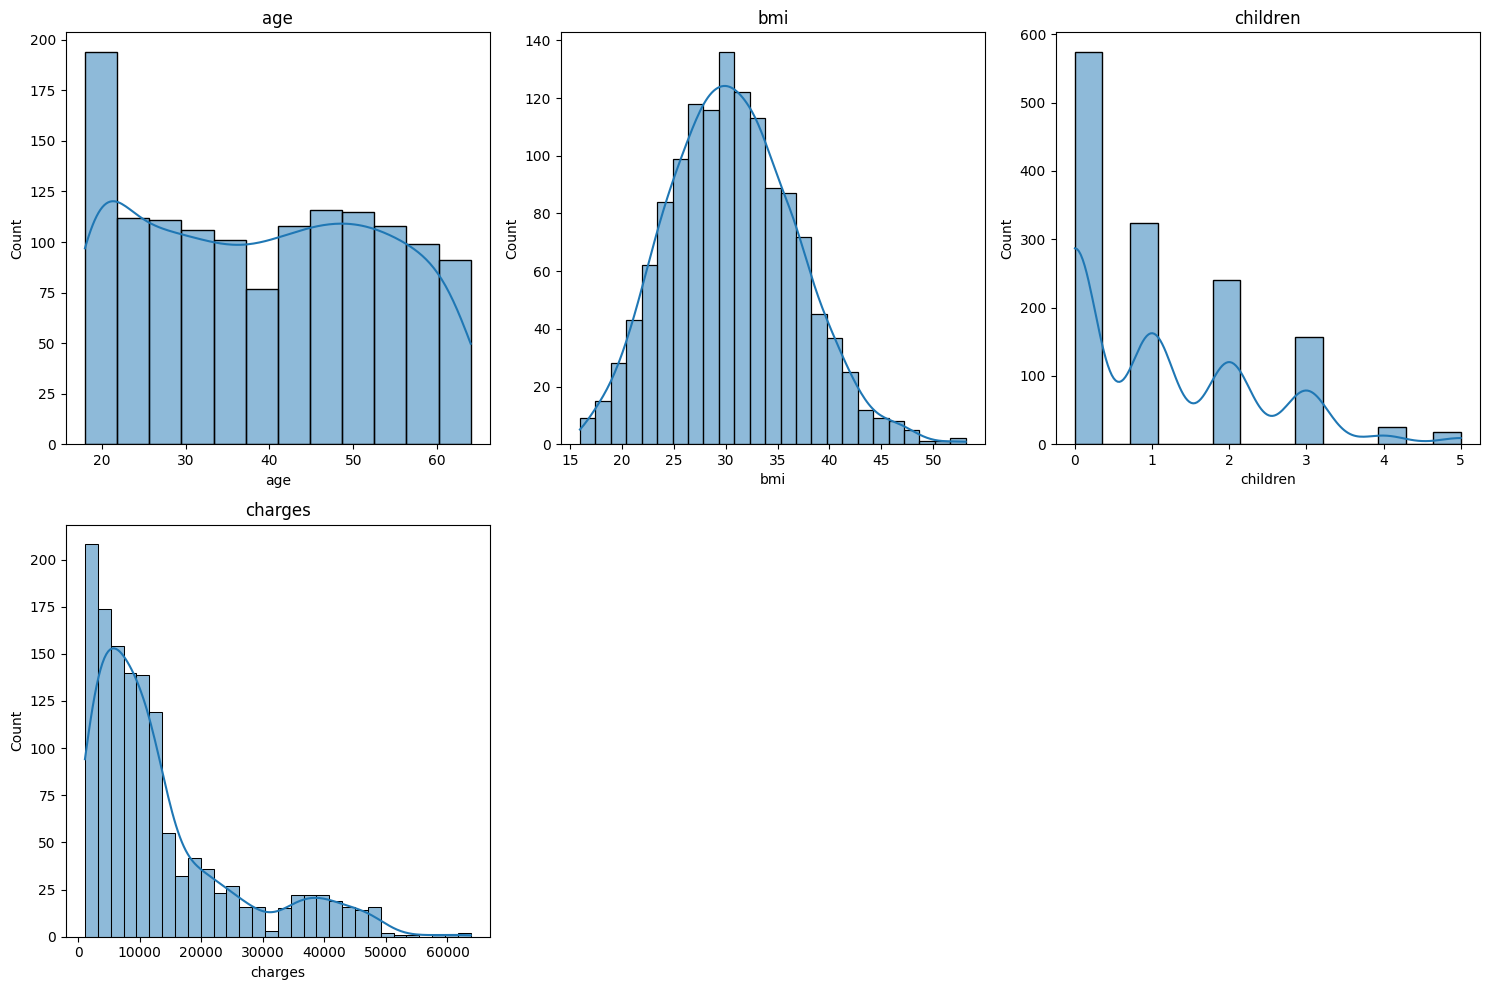

In [34]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(num_df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

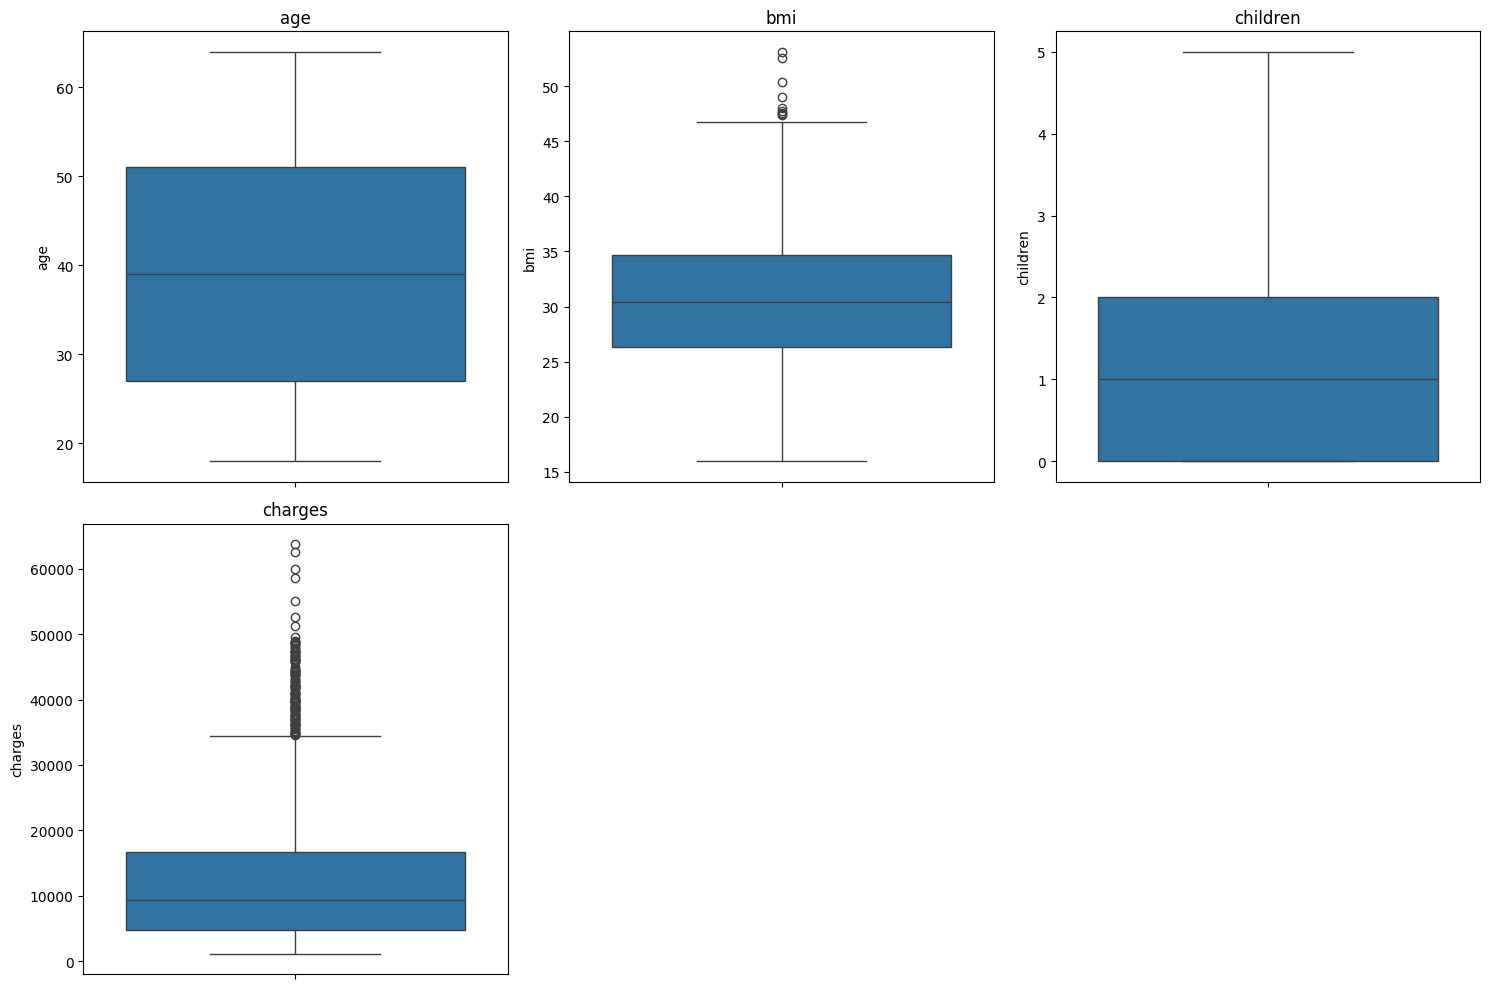

In [35]:
cols = num_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(num_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

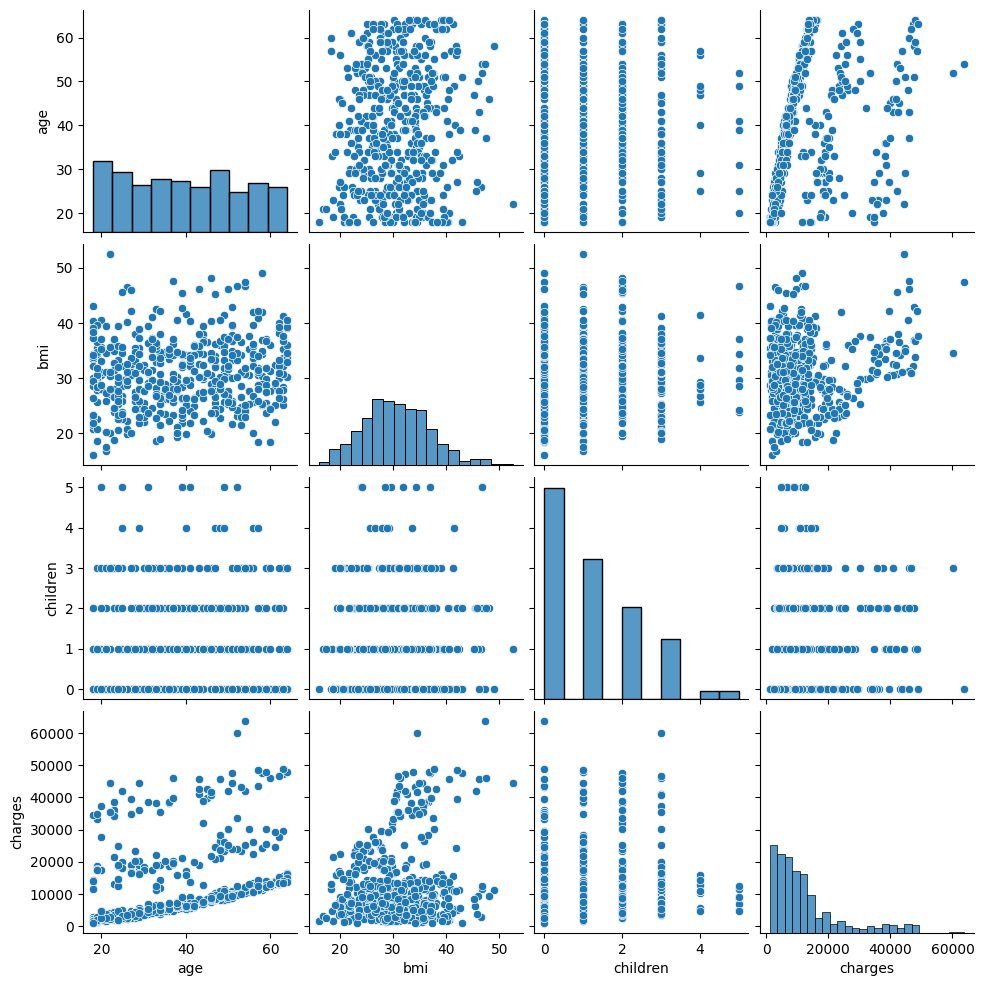

In [36]:
sns.pairplot(num_df.sample(500))

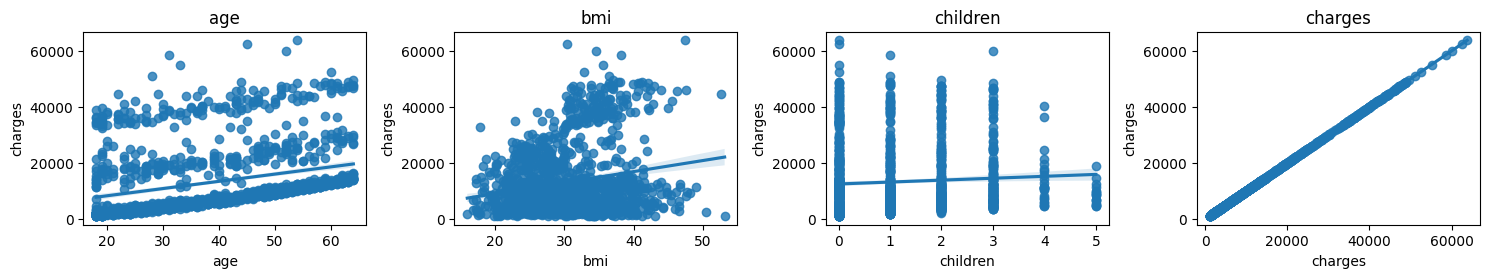

In [38]:
num_cols = num_df

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.regplot(x=num_df[col], y=num_df["charges"])
    plt.title(col)
plt.tight_layout()
plt.show()

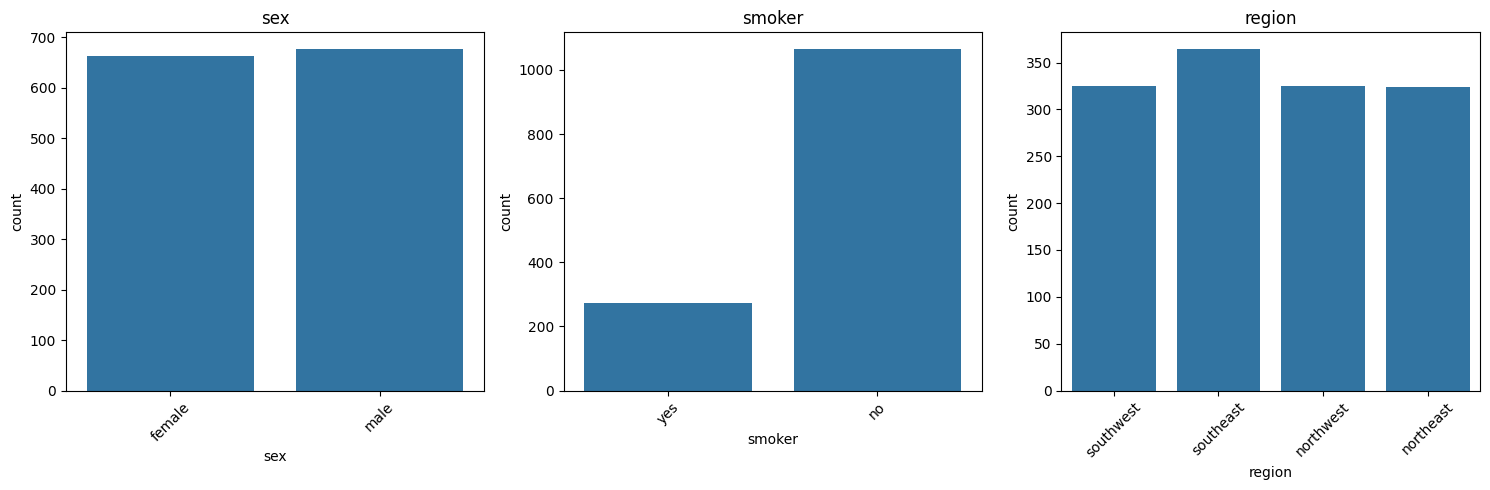

In [39]:
cols = cat_df.columns
n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(x=cat_df[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ***Data Preprocessing***

In [40]:
for col in num_df:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    num_df[col] = num_df[col].clip(lower, upper)


In [43]:
encoder = LabelEncoder()
for col in cat_df:
    cat_df[col] = encoder.fit_transform(cat_df[col])

In [46]:
df = pd.concat([num_df,cat_df],axis=1)
df.head()

,age,bmi,children,charges,sex,smoker,region,sex,smoker,region
0,1,197,0,1005,0,1,3,0,1,3
1,0,350,1,57,1,0,2,1,0,2
2,10,331,3,306,1,0,2,1,0,2
3,15,73,0,1097,1,0,1,1,0,1
4,14,223,0,254,1,0,1,1,0,1


In [47]:
X = df.drop("charges",axis=1)
y = df["charges"]

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    "Ridge": {
        "model": Ridge(),
        "params": {"alpha": [0.01, 0.1, 1, 10]}
    },
    "Lasso": {
        "model": Lasso(max_iter=5000),
        "params": {"alpha": [0.001, 0.01, 0.1, 1]}
    },
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {"n_neighbors": [3, 5, 7, 9]}
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "kernel": ["linear", "poly", "rbf"],
            "C": [0.1, 1, 10, 100],
            "epsilon": [0.01, 0.1, 0.2]
        }
    },
    "DecisionTree": {
        "model": DecisionTreeRegressor(),
        "params": {"max_depth": [None, 5, 10, 20]}
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1]}
    },
    "XGBoost": {
        "model": XGBRegressor(objective='reg:squarederror', verbosity=0),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1], "max_depth": [3, 6]}
    },
    "LightGBM": {
        "model": LGBMRegressor(),
        "params": {"n_estimators": [100, 200], "learning_rate": [0.01, 0.1]}
    },
    "CatBoost": {
        "model": CatBoostRegressor(verbose=0),
        "params": {"iterations": [200, 500], "learning_rate": [0.01, 0.1], "depth": [4, 6]}
    }
}

In [51]:
results = []

for name, config in models.items():

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "RMSE": rmse,
        "MAE": mae
    })

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 332
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 9
[LightGBM] [Info] Start training from score 667.451402


In [52]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Best Params,Train R2,Test R2,RMSE,MAE
0,GradientBoosting,"{'learning_rate': 0.1, 'n_estimators': 100}",0.851674,0.846270,151.199838,81.419969
1,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.842743,0.846058,151.304529,80.322510
2,CatBoost,"{'depth': 4, 'iterations': 500, 'learning_rate...",0.814293,0.843728,152.444894,87.746107
3,SVR,"{'C': 100, 'epsilon': 0.2, 'kernel': 'rbf'}",0.787763,0.837758,155.329709,50.527655
4,DecisionTree,{'max_depth': 5},0.808169,0.829531,159.219048,89.300488
5,RandomForest,"{'max_depth': 10, 'n_estimators': 200}",0.949053,0.825638,161.026864,78.913982
6,LightGBM,"{'learning_rate': 0.01, 'n_estimators': 200}",0.826045,0.819746,163.725017,106.411042
7,KNN,{'n_neighbors': 9},0.814814,0.799708,172.585639,103.305141
8,LinearRegression,{},0.730923,0.779144,181.228890,129.199280
9,Lasso,{'alpha': 0.1},0.730922,0.779121,181.238302,129.222045


In [55]:
final_model = GradientBoostingRegressor(learning_rate=0.1, n_estimators=100)
final_model.fit(X_train, y_train)

GradientBoostingRegressor()

In [63]:
importances = final_model.feature_importances_

feature_names = df.drop(columns=['charges']).columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

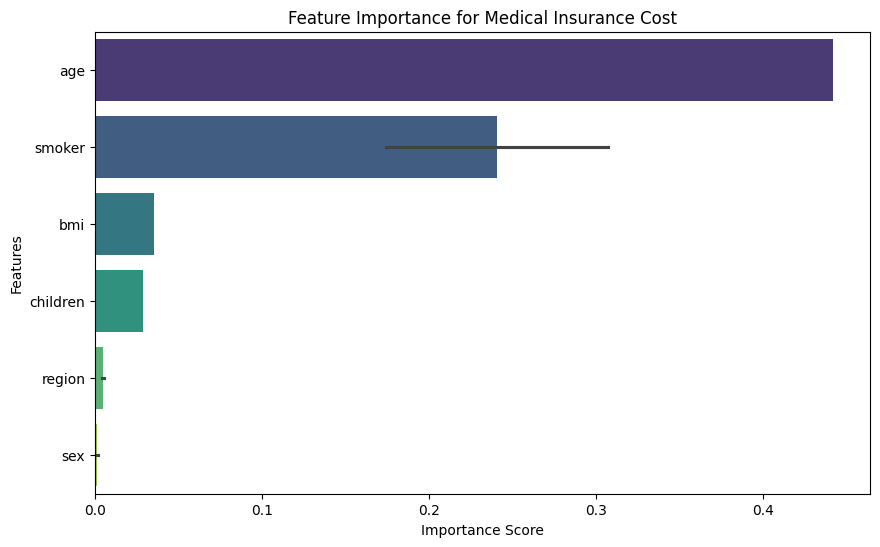

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance for Medical Insurance Cost')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

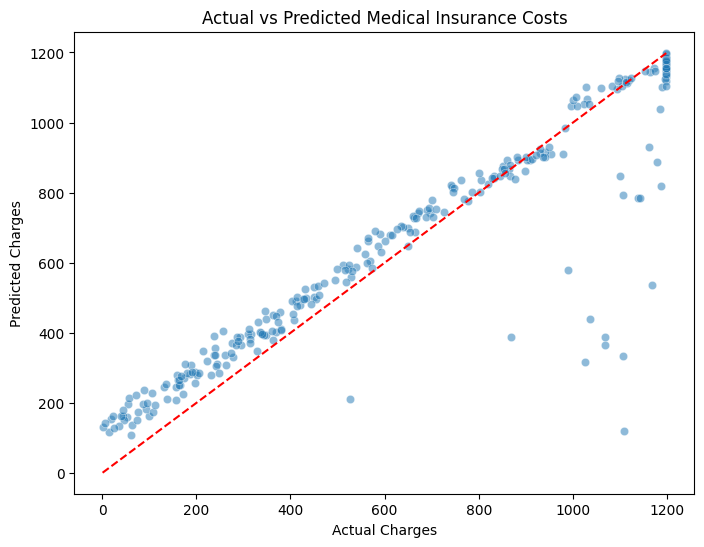

In [66]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Medical Insurance Costs')
plt.show()